This notebook is used to check the heritability and disease relationships of the ICD Genetic Network

In [114]:

import obonet
import networkx as nx
import os
import sys
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import os.path
import pandas as pd
from collections import (defaultdict,Counter)
import seaborn as sns
import matplotlib.pyplot as plt


In [145]:
#Let's import the Genetic Heridatability Predictions from https://h2.cpr.ku.dk/icd10rglvl3.php

heritability_df = pd.read_csv("input/website_icd10_rg_lvl3.tsv", sep="\t")

In [147]:
#Let's create a dictionary where we extract the median genetic similarity between two diseases

ICD_heritability = {}
for i,v in heritability_df.iterrows():
    ICD_heritability[v['A'],v['B']] = v['X50_']
    


In [24]:
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [26]:
doid_icd10_df = pd.read_csv("input/GDA/ICD10inDO.tsv", sep="\t")

In [28]:

icd10_do_name_dict = {}
icd10_do_doid_dict = {}

for i,v in doid_icd10_df.iterrows():
    icdterm = v['xrefs'].split(":")[1].split(".")[0]
    name = v['label'].split("@")[0]
    doid = v['id']
    if "," in icdterm:
        real_icd = icdterm.split(",")[0]
        icd10_do_name_dict[real_icd] = name
        icd10_do_doid_dict[real_icd] = doid
    else:
        icd10_do_name_dict[icdterm] = name
        icd10_do_doid_dict[icdterm] = doid

print(len(icd10_do_name_dict))
print(len(icd10_do_doid_dict))

867
867


In [31]:
icd10_do_doid_dict_rev = {}

for k,v in icd10_do_doid_dict.items():
    icd10_do_doid_dict_rev[v] = k

In [9]:
#Let's try to agglomerate diseases based on the disease ontology

#First
#Let's import the obo file for DOID 

url = 'https://raw.githubusercontent.com/DiseaseOntology/HumanDiseaseOntology/master/src/ontology/HumanDO.obo'
graph = obonet.read_obo(url)


In [20]:
       
#This function calculates the Jaccard Index between two lists
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

#This function is the first step for the resnik score calculation
def precalc_lower_bounds(G):
    """Pre-calculate the number of lower bounds of the graph nodes
    """
    G.lower_bounds = Counter()
    for n in G:
        G.lower_bounds[n] += 1
        for ans in nx.ancestors(G, n):
            G.lower_bounds[ans] += 1
   # G.descriptors.add("Pre-calculated lower bounds")
#This function is the second step for the resnik score calculation
def information_content(G, term):
    """Information content
    Args:
        G(Ontology Graph): Ontology graph object
        term(str): ontolgy term
    Returns:
        str - Information content
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term not in G.lower_bounds:
        raise exception.PGSSLookupError(f"Missing term: {term}")
    freq = G.lower_bounds[term] / len(G)
    return round(-1 * math.log2(freq), 3)

#This function is the third step for the resnik score calculation
def lowest_common_ancestor(G, term1, term2):
    """Naive implementation of lowest common ancestor (LCA)
    Args:
        G(GoGraph): Graph object
        term1(str): Ontology term 1
        term2(str): Ontology term 2
    Returns:
        str - Lowest common ancestor term
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term1 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term1}")
    if term2 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term2}")
    lb1 = nx.ancestors(G, term1) | {term1}
    lb2 = nx.ancestors(G, term2) | {term2}
    common_ans = lb1 & lb2
    if not common_ans:
        return
    return min(common_ans, key=lambda x: G.lower_bounds[x])
import math
#This function would return the resnik score between two terms
def resnik(G, term1, term2):
    """Semantic similarity based on Resnik method
    Args:
        G(GoGraph): Ontology graph object
        term1(str): term 1
        term2(str): term 2
    Returns:
        float - Resnik similarity value (Information content of LCA)
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in GoGraph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    mica = lowest_common_ancestor(G, term1, term2)
    if mica is not None:
        return information_content(G, mica)
    



In [71]:
print(len(set(icd10_do_doid_dict_rev.values())&set(allsources_icd_gene_dict_unified.keys())))

743


In [80]:
G_down = nx.DiGraph.reverse(graph)

In [83]:

precalc_lower_bounds(G_down)

In [ ]:
pairwise_list = list(it.combinations(G_down.nodes(), 2))

In [ ]:
G_down_resnik = {}
for i,j in pairwise_list:
    G_down_resnik[i,j] = round(resnik(G_down, i, j),3)

In [ ]:
with open('output/G_down_resnik.pickle', 'wb') as handle:
    pk.dump(G_down_resnik, handle, protocol=pk.HIGHEST_PROTOCOL)

In [91]:
with open('output/G_down_resnik.pickle', 'rb') as handle:
    G_down_resnik = pk.load(handle)

In [92]:
#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')


In [108]:
#Let's select the resnik found in the edges of the ICD Genetic network and an equal number of disease pairs
#that are not in the ICD Genetic network

G_gene_icd_disp_significant_post_edges = list(G_gene_icd_disp_significant_post.edges())

G_gene_icd_disp_significant_post_edges_resnik_dict = {}
for e in G_gene_icd_disp_significant_post_edges:
    try:
        try:
            G_gene_icd_disp_significant_post_edges_resnik_dict[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]] = G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]]
        except:
            G_gene_icd_disp_significant_post_edges_resnik_dict[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]] = G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]]
    except:
        pass
            


In [109]:

dispair_no_genetic_network_list = []
for dis_pair in G_down_resnik.keys():
    if dis_pair not in G_gene_icd_disp_significant_post_edges_resnik_dict.keys():
        dispair_no_genetic_network_list.append(dis_pair)
        
random_equal_number = rd.sample(dispair_no_genetic_network_list,len(G_gene_icd_disp_significant_post_edges_resnik_dict))
random_resnik_equal_number = {}
for dispair in random_equal_number:
    random_resnik_equal_number[dispair] = G_down_resnik[dispair]


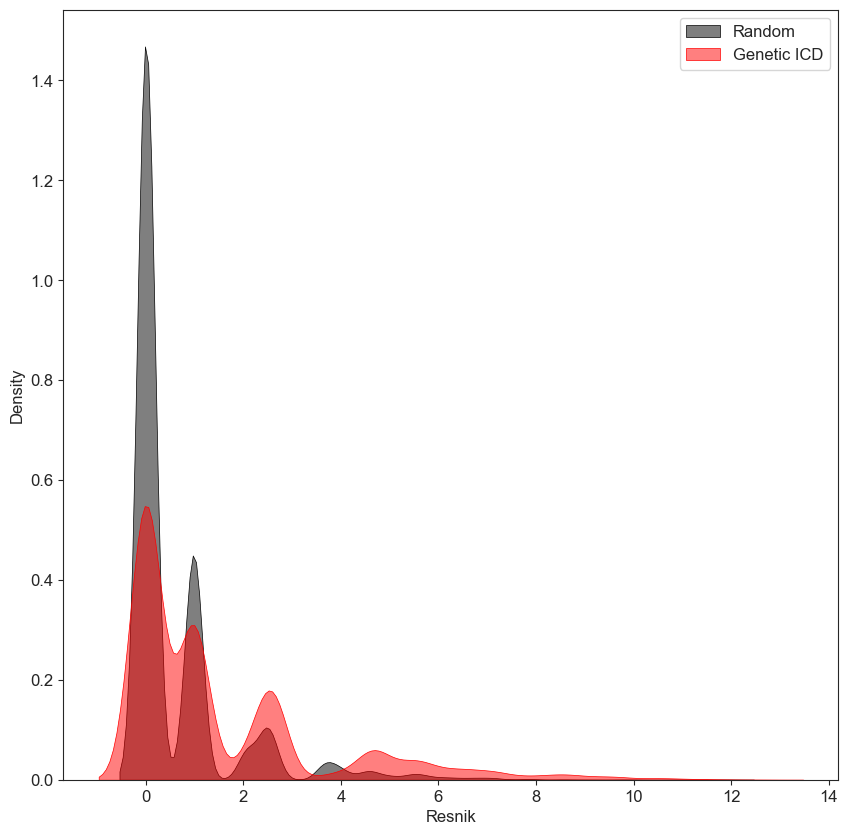

In [118]:
#Let's plot the distribution of all lcc z-scores

genetic_icd_resnik = [i for i in G_gene_icd_disp_significant_post_edges_resnik_dict.values() if str(i)!='nan']
random_resnik = [i for i in random_resnik_equal_number.values() if str(i)!='nan']

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
sns.kdeplot(random_resnik,color='k',lw=.5,alpha=.5,fill=True,label='Random')
sns.kdeplot(genetic_icd_resnik,color='r',lw=.5,alpha=.5,fill=True,label='Genetic ICD')

plt.legend(loc='upper right',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Resnik',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/Resnik_Comparison_Random_GeneticICD.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [119]:
from scipy.stats import mannwhitneyu

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(genetic_icd_resnik, random_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=99322129.5, pvalue=0.0)

In [120]:
np.median(genetic_icd_resnik)

0.978

In [121]:
np.median(random_resnik)

0.0

In [122]:
#Let's extract the ICD categories
icd_cat = set([str(n[0]) for n in G_gene_icd_disp_significant_post.nodes()])
#Let's group the diseases of the ICD Genetic network based on the ICD categories
G_gene_icd_ICD_partition = {}
for icd in icd_cat:
    dislist = []
    for node in G_gene_icd_disp_significant_post.nodes():
        if icd in node:
            dislist.append(node)
    G_gene_icd_ICD_partition[icd] = dislist

In [124]:
#Let's import the Louvain communities
with open('output/G_gene_icd_com.pickle', 'rb') as handle:
    G_gene_icd_com = pk.load(handle)

In [126]:
#Let's select all disease-pairs edges between the ICD disease categories

G_gene_icd_ICD_partition_edges = {}
for cat,dis_list in G_gene_icd_ICD_partition.items():
    dis_pairwise_list = list(it.combinations(dis_list, 2))
    dis_pairwise_list_edges = []
    for dis_pair in dis_pairwise_list:
        if (dis_pair[0],dis_pair[1]) in G_gene_icd_disp_significant_post_edges or (dis_pair[1],dis_pair[0]) in G_gene_icd_disp_significant_post_edges:
            dis_pairwise_list_edges.append(dis_pair)
    G_gene_icd_ICD_partition_edges[cat] = dis_pairwise_list_edges

G_gene_icd_com_edges = {}
for com,dis_list in G_gene_icd_com.items():
    dis_pairwise_list = list(it.combinations(dis_list, 2))
    dis_pairwise_list_edges = []
    for dis_pair in dis_pairwise_list:
        if (dis_pair[0],dis_pair[1]) in G_gene_icd_disp_significant_post_edges or (dis_pair[1],dis_pair[0]) in G_gene_icd_disp_significant_post_edges:
            dis_pairwise_list_edges.append(dis_pair)
    G_gene_icd_com_edges[com] = dis_pairwise_list_edges
    

In [132]:
#Let's extract the median resnik for each category
G_gene_icd_ICD_partition_edges_median_resnik = {}
for cat,edgelist in G_gene_icd_ICD_partition_edges.items():
    resnik_list = []
    for e in edgelist:
        try:
            try:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]])
            except:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]])
        except:
            pass
    resnik_list_cl = [i for i in resnik_list if str(i)!='nan']
    G_gene_icd_ICD_partition_edges_median_resnik[cat] = np.median(resnik_list_cl)

#Let's extract the median resnik for each category
G_gene_icd_com_edges_median_resnik = {}
for com,edgelist in G_gene_icd_com_edges.items():
    resnik_list = []
    for e in edgelist:
        try:
            try:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]])
            except:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]])
        except:
            pass
    resnik_list_cl = [i for i in resnik_list if str(i)!='nan']
    G_gene_icd_com_edges_median_resnik[com] = np.median(resnik_list_cl)
            

In [135]:
#Let's select 10,000 random resnik values

random_resnik_number = rd.sample(list(G_down_resnik.values()),10000)


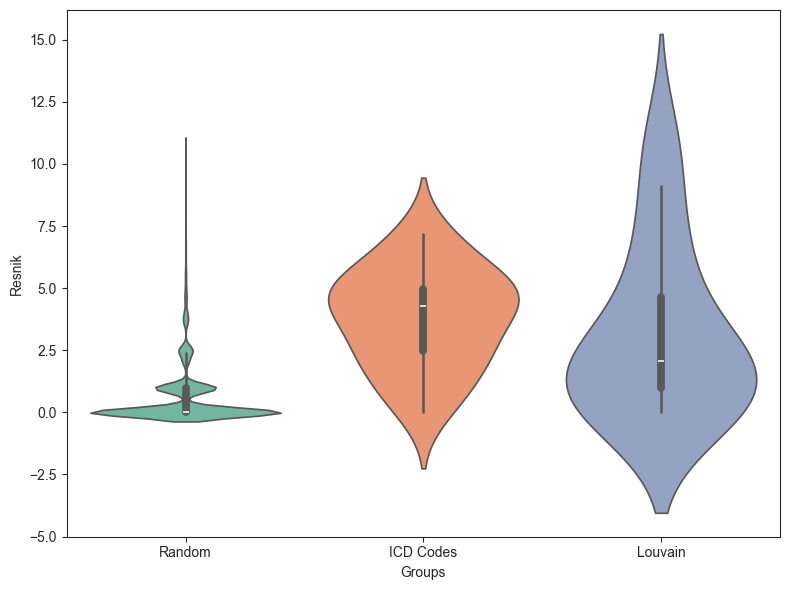

In [138]:
ICD_avg_resnik = [i for i in G_gene_icd_ICD_partition_edges_median_resnik.values() if str(i)!='nan']
Louvain_avg_resnik = [i for i in G_gene_icd_com_edges_median_resnik.values() if str(i)!='nan']

# Combine the data into a single structure for plotting
avg_resnik_plot = [random_resnik_number, ICD_avg_resnik, Louvain_avg_resnik]

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(data=avg_resnik_plot, palette="Set2")

# Customize the plot
plt.xticks([0, 1, 2], ['Random', 'ICD Codes', 'Louvain'])  # X-axis labels
plt.ylabel('Resnik')
plt.xlabel('Groups')

# Show the plot
plt.tight_layout()
plt.savefig('Figures/Resnik_Comparison_Random_GeneticICD_Violin.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [139]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(random_resnik_number, ICD_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=16059.0, pvalue=5.653134801759386e-13)

In [140]:
np.median(ICD_avg_resnik)

4.276

In [142]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(random_resnik_number, Louvain_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=32228.5, pvalue=4.869675104985945e-06)

In [143]:
np.median(Louvain_avg_resnik)

2.062

In [144]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(ICD_avg_resnik, Louvain_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=172.0, pvalue=0.18517609462359663)

In [152]:
#Let's compare the genetic overlap in the ICD Genetic Network and the resnik

G_gene_icd_disp_significant_post_edges_resnik_dict = {}
G_gene_icd_disp_significant_post_edges_genetic_overlap_dict = {}

for e in G_gene_icd_disp_significant_post_edges:
    try:
        try:
            G_gene_icd_disp_significant_post_edges_resnik_dict[e[0],e[1]] = G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]]
            G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        except:
            G_gene_icd_disp_significant_post_edges_resnik_dict[e[0],e[1]] = G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]]
            G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
    except:
        pass
            


In [153]:
len(G_gene_icd_disp_significant_post_edges_resnik_dict)==len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict)

True

In [163]:

G_gene_icd_disp_significant_post_edges_resnik_list = []
G_gene_icd_disp_significant_post_edges_genetic_overlap_list = []
for dispair,resnik in G_gene_icd_disp_significant_post_edges_resnik_dict.items():
    G_gene_icd_disp_significant_post_edges_resnik_list.append(resnik)
    G_gene_icd_disp_significant_post_edges_genetic_overlap_list.append(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[dispair])
    


In [162]:
import scipy  
from scipy import stats
print(scipy.stats.pearsonr(G_gene_icd_disp_significant_post_edges_genetic_overlap_list,G_gene_icd_disp_significant_post_edges_resnik_list))  # Pearson's r
print(scipy.stats.spearmanr(G_gene_icd_disp_significant_post_edges_genetic_overlap_list,G_gene_icd_disp_significant_post_edges_resnik_list)) # Spearman's rho

PearsonRResult(statistic=0.22075901831593936, pvalue=9.585224678665754e-138)
SignificanceResult(statistic=0.2312152798919778, pvalue=2.8284803279517016e-151)


In [159]:

resnik_list_1=[]
resnik_list_2=[]
resnik_list_3=[]
resnik_list_4=[]
resnik_list_5=[]
resnik_list_6=[]
resnik_list_7=[]
resnik_list_8=[]
resnik_list_9=[]
resnik_list_10=[]


for dis_pair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    if ji<0.1:
        resnik_list_1.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>0.1 and ji<2*0.1:
        resnik_list_2.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>2*0.1 and ji<3*0.1:
        resnik_list_3.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>3*0.1 and ji<4*0.1:
        resnik_list_4.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>4*0.1 and ji<5*0.1:
        resnik_list_5.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>5*0.1 and ji<6*0.1:
        resnik_list_6.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>6*0.1 and ji<7*0.1:
        resnik_list_7.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>7*0.1 and ji<8*0.1:
        resnik_list_8.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>8*0.1 and ji<9*0.1:
        resnik_list_9.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    else:
        resnik_list_10.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])

In [160]:

column_names = ["Resnik", "JI"]

resnik_list_tot=[]
group_list=[]
for i in resnik_list_1:
    resnik_list_tot.append(i)
    group_list.append("<10%")
    
for i in resnik_list_2:
    resnik_list_tot.append(i)
    group_list.append("10%-20%")

for i in resnik_list_3:
    resnik_list_tot.append(i)
    group_list.append("20%-30%")
    
for i in resnik_list_4:
    resnik_list_tot.append(i)
    group_list.append("30%-40%")
    
for i in resnik_list_5:
    resnik_list_tot.append(i)
    group_list.append("40%-50%")

for i in resnik_list_6:
    resnik_list_tot.append(i)
    group_list.append("50%-60%")

for i in resnik_list_7:
    resnik_list_tot.append(i)
    group_list.append("60%-70%")
    
for i in resnik_list_8:
    resnik_list_tot.append(i)
    group_list.append("70%-80%")
    
for i in resnik_list_9:
    resnik_list_tot.append(i)
    group_list.append("80%-90%")

for i in resnik_list_10:
    resnik_list_tot.append(i)
    group_list.append("90%-100%")
    
    
Resnik_JI_df = pd.DataFrame(columns = column_names)
Resnik_JI_df["Resnik"]=resnik_list_tot
Resnik_JI_df["JI"]=group_list

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_86601/2228638470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="JI", y="Resnik", data=Resnik_JI_df,errorbar='se',


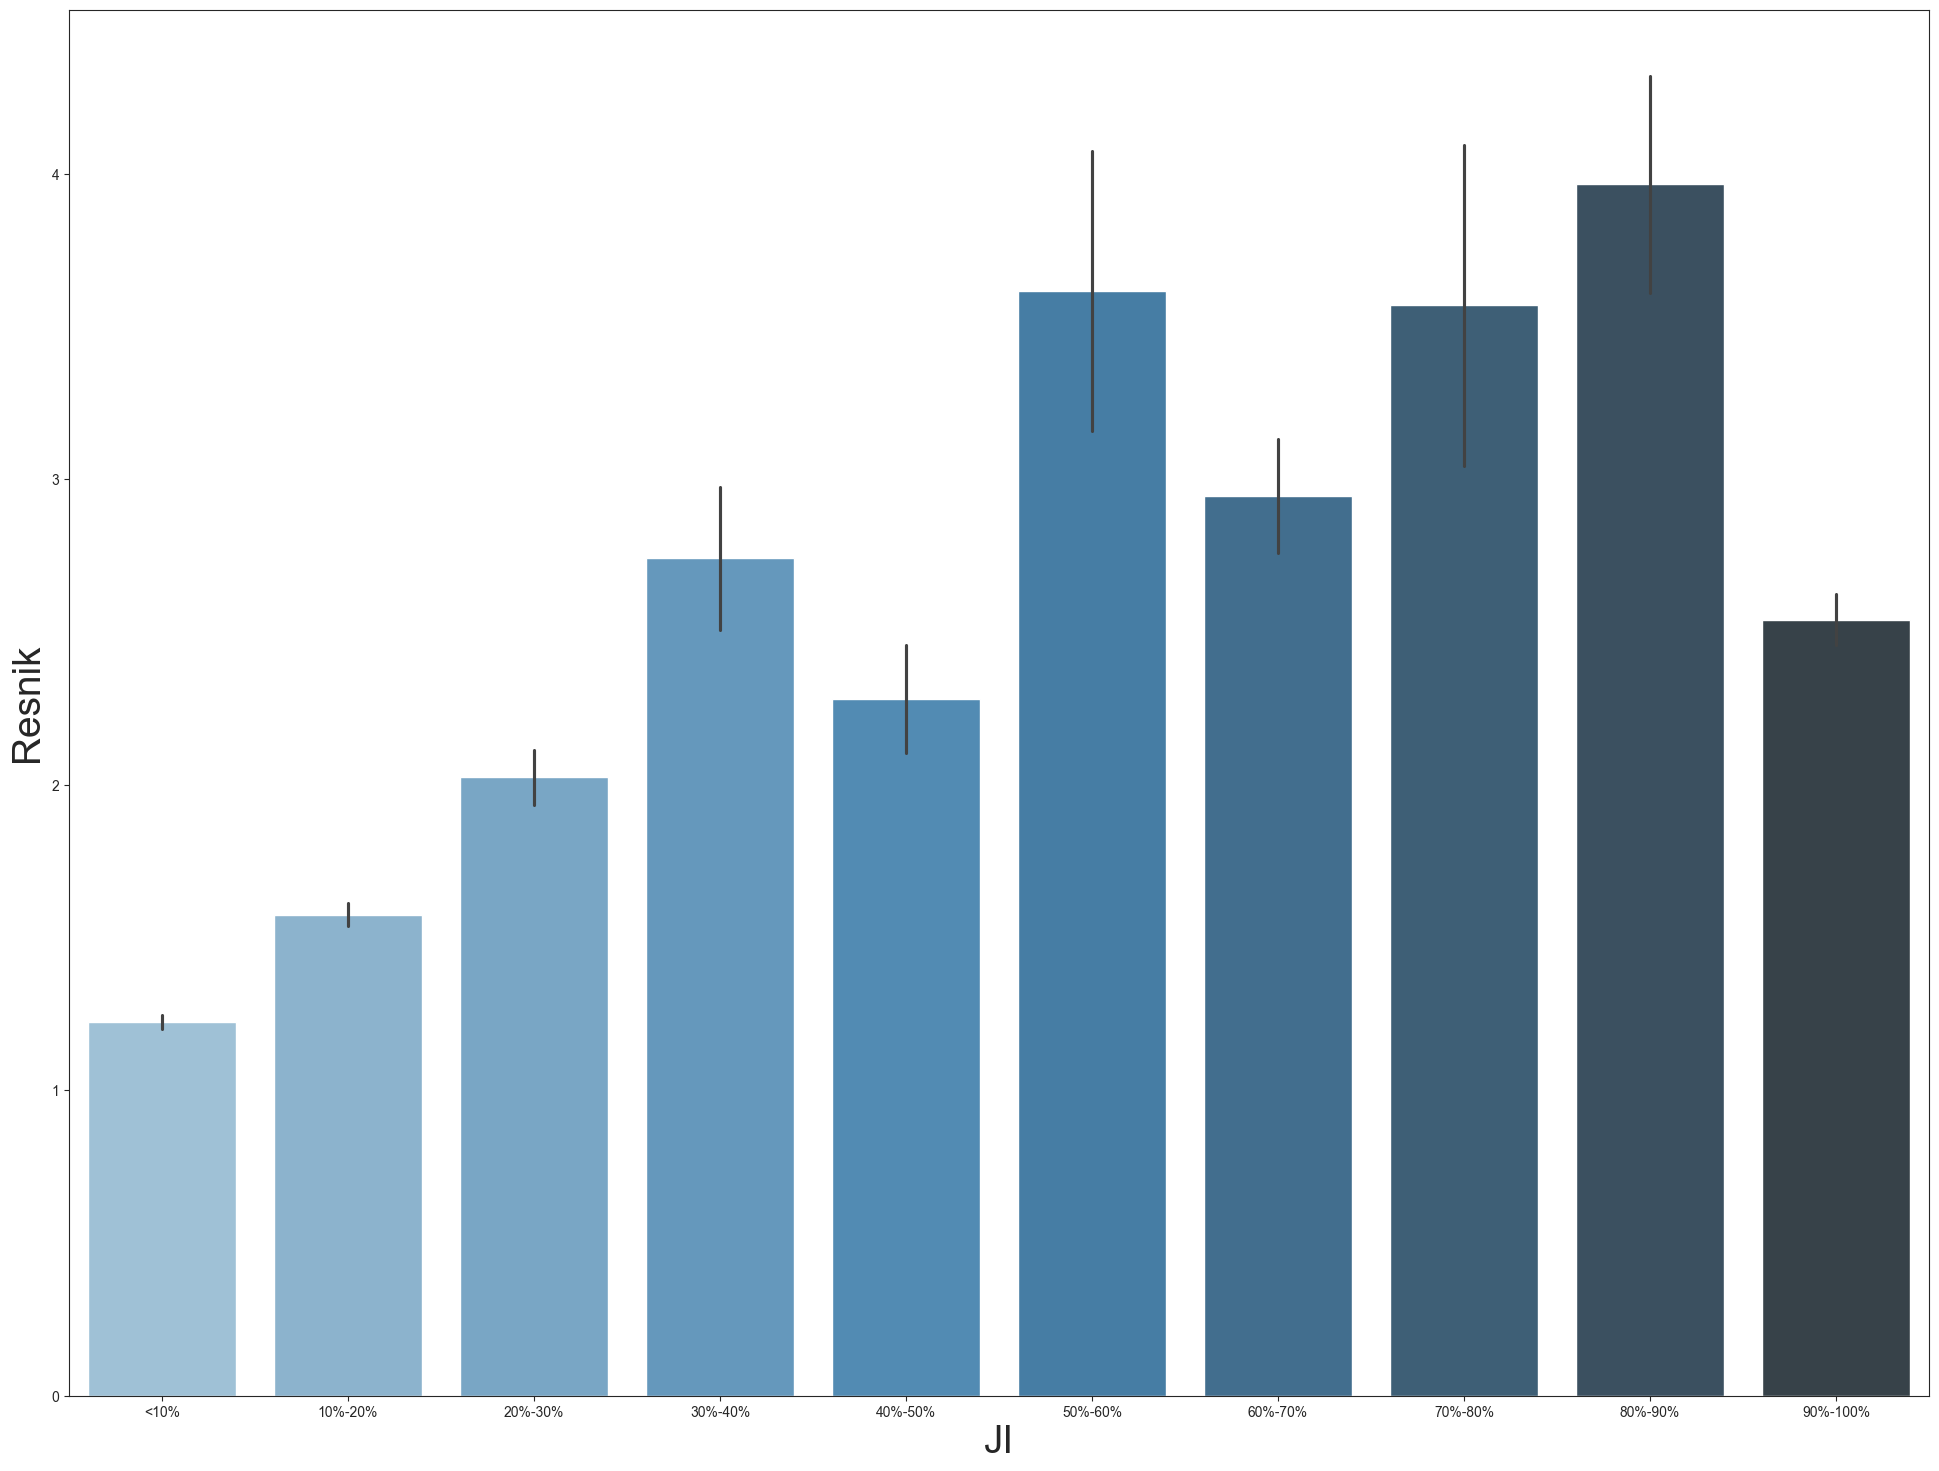

In [164]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(24, 18))
ax = sns.barplot(x="JI", y="Resnik", data=Resnik_JI_df,errorbar='se',
                 palette="Blues_d")
#ax.set_yscale("log")
ax.set_ylabel("Resnik",fontsize=28)
ax.set_xlabel("JI",fontsize=28)
plt.savefig('Figures/Resnik_JI_Grouped_Correlation.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [167]:
#Let's check now whether we have a similar trend between the genetic and the heritability



G_gene_icd_disp_significant_post_edges_genetic_overlap_dict = {}
G_gene_icd_disp_significant_post_edges_heritability_dict = {}

for e in G_gene_icd_disp_significant_post_edges:
    if (e[0],e[1]) in ICD_heritability.keys():
        G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        G_gene_icd_disp_significant_post_edges_heritability_dict[e[0],e[1]] = ICD_heritability[(e[0],e[1])]
    elif (e[1],e[0]) in ICD_heritability.keys():
        G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        G_gene_icd_disp_significant_post_edges_heritability_dict[e[0],e[1]] = ICD_heritability[(e[1],e[0])]


In [170]:
print(len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict)==len(G_gene_icd_disp_significant_post_edges_heritability_dict))
print(len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict))

True
2396


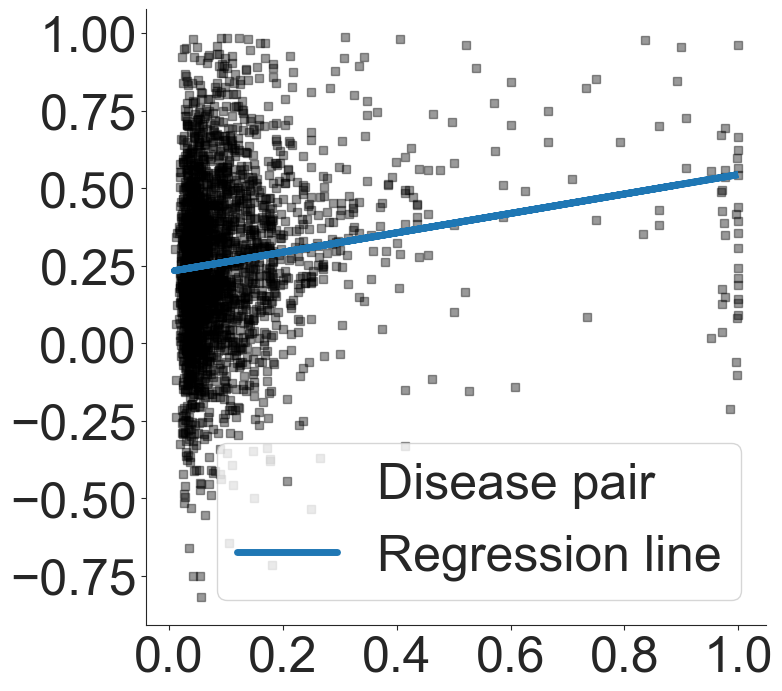

In [174]:
from matplotlib.pyplot import figure
import scipy  
from scipy import stats
fig, ax = plt.subplots(figsize=(8,8))

G_gene_icd_ji_list = []
G_gene_icd_heritability_list = []

for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    G_gene_icd_ji_list.append(ji)
    G_gene_icd_heritability_list.append(G_gene_icd_disp_significant_post_edges_heritability_dict[dispair])
    


slope, intercept, r, p, stderr = scipy.stats.linregress(G_gene_icd_ji_list, G_gene_icd_heritability_list)

ax.plot(G_gene_icd_ji_list,G_gene_icd_heritability_list, linewidth=0, marker='s', c='k',label='Disease pair', alpha=0.4)
y=[]
for i in G_gene_icd_ji_list:
    g=(intercept + slope * i)
    y.append(g)
line = "Regression line" 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.plot(G_gene_icd_ji_list, y, label=line,linewidth=5)
plt.xticks(fontsize=36) 
plt.yticks(fontsize=36) 
ax.legend(facecolor='white',fontsize=36)


plt.savefig('Figures/JI_Heritability_Correlation.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

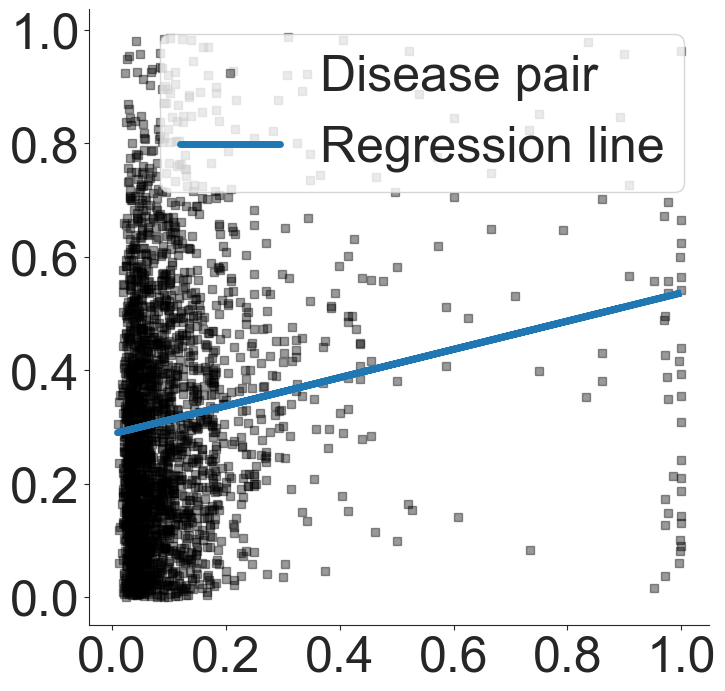

In [175]:
#Let's take only the absolute number of correlation because we are not taking into account the direction of genetic
#similarity
from matplotlib.pyplot import figure
import scipy  
from scipy import stats
fig, ax = plt.subplots(figsize=(8,8))

G_gene_icd_ji_list = []
G_gene_icd_heritability_list = []

for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    G_gene_icd_ji_list.append(ji)
    G_gene_icd_heritability_list.append(np.abs(G_gene_icd_disp_significant_post_edges_heritability_dict[dispair]))
    


slope, intercept, r, p, stderr = scipy.stats.linregress(G_gene_icd_ji_list, G_gene_icd_heritability_list)

ax.plot(G_gene_icd_ji_list,G_gene_icd_heritability_list, linewidth=0, marker='s', c='k',label='Disease pair', alpha=0.4)
y=[]
for i in G_gene_icd_ji_list:
    g=(intercept + slope * i)
    y.append(g)
line = "Regression line" 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.plot(G_gene_icd_ji_list, y, label=line,linewidth=5)
plt.xticks(fontsize=36) 
plt.yticks(fontsize=36) 
ax.legend(facecolor='white',fontsize=36)

plt.savefig('Figures/JI_Heritability_Correlation_absolute.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [173]:
import scipy  
from scipy import stats
print(scipy.stats.pearsonr(G_gene_icd_ji_list,G_gene_icd_heritability_list))  # Pearson's r
print(scipy.stats.spearmanr(G_gene_icd_ji_list,G_gene_icd_heritability_list)) # Spearman's rho



PearsonRResult(statistic=0.16845641916307263, pvalue=1.0337002988735282e-16)
SignificanceResult(statistic=0.1770391685949143, pvalue=2.537570337740934e-18)


In [177]:
#Let's print some examples
for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    if ji>0.8 and G_gene_icd_disp_significant_post_edges_heritability_dict[dispair]>0.8:
        print(dispair)
        

('E14', 'E11')
('E11', 'E10')
('F60', 'F61')
('H66', 'H65')


In [178]:
len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict)

2396

In [181]:
G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[('E11', 'E10')]

0.8995348837209303